In [190]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

In [191]:
X = np.array([
    [1,4,1.5,3.8],
    [3,6,1.0,3.1],
    [4,7,0.8,3.9],
    [6,8,0.4,3.4],
    [7,9,0.2,2.8]
])

Y = np.array([45, 60, 72, 85, 95])

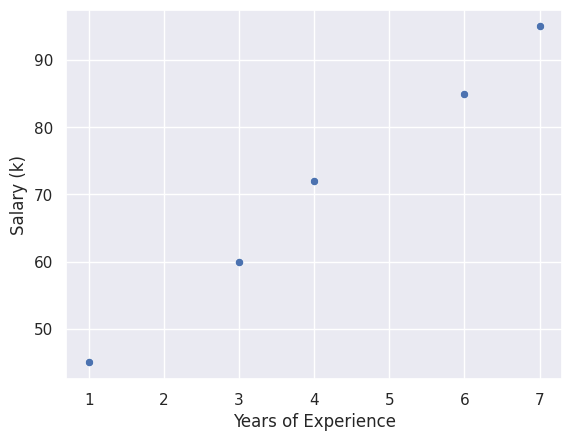

In [192]:
sns.scatterplot(x=X[:, 0:1].ravel(), y=Y)

plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.show()

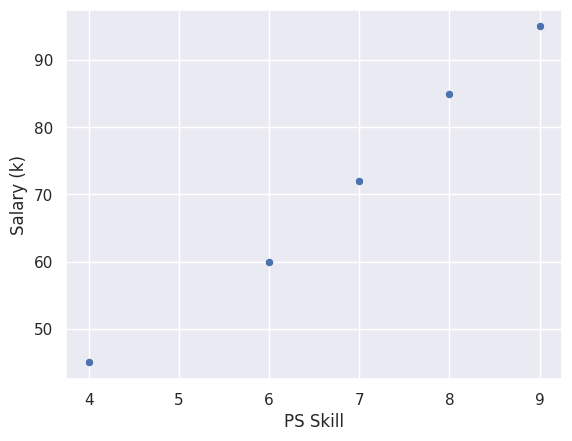

In [193]:
sns.scatterplot(x=X[:, 1:2].ravel(), y=Y)

plt.xlabel("PS Skill")
plt.ylabel("Salary (k)")
plt.show()

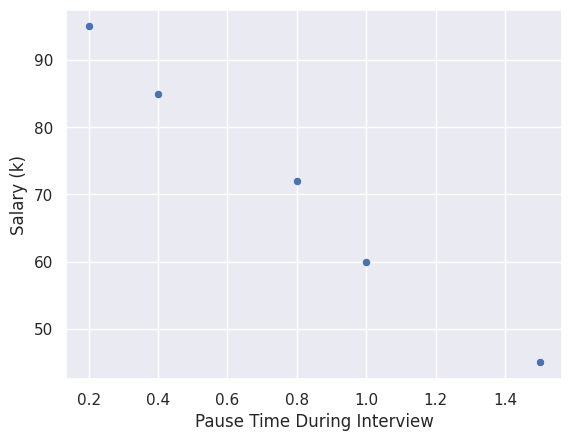

In [194]:
sns.scatterplot(x=X[:, 2:3].ravel(), y=Y)

plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary (k)")
plt.show()

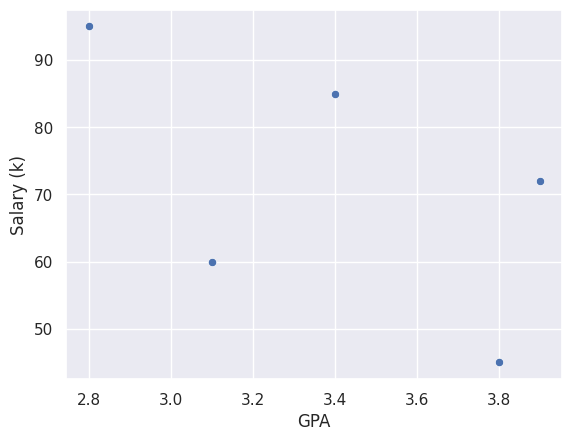

In [195]:
sns.scatterplot(x=X[:, 3:4].ravel(), y=Y)

plt.xlabel("GPA")
plt.ylabel("Salary (k)")
plt.show()

In [196]:
def make_predict(X, W, b):
  # Calculates the model output: f(x) = wx +b

  m = X.shape[0] # Number of training examples

  pred_list = np.zeros((m,)) # Initialize an array to store results

  for i in range(m):
    # X[i] = feature vector, w = weights_vector
    pred_list[i] = np.dot(W, X[i]) + b

  return pred_list

In [197]:
m = X.shape[0] # row
n = X.shape[1] # col


W_init = np.ones((n,))

b_init = 1.0


make_predict(X, W_init, b_init)

array([11.3, 14.1, 16.7, 18.8, 20. ])

In [198]:
def compute_cost(X, y, W, b):
  # Calculates the Mean Squared Error (MSE) to measure model accuracy

  m = X.shape[0] # Number of training examples
  cost = 0.0

  pred_list = make_predict(X, W,b) # Initialize

  #print(pred_list)

  error = (pred_list - y)

  #print(error)

  error_squared = error ** 2

  #print(error_squared)

  cost = (1 / (2 * m)) * np.sum(error_squared)

  return cost

In [199]:
m = X.shape[0] # row
n = X.shape[1] # col


W_init = np.ones((n,))

b_init = 1.0

compute_cost(X, Y, W_init, b_init)

np.float64(1630.803)

In [200]:
def calculate_gradient(X, y, W, b):
  # Computes the gradient (direction to move) for W and b

  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,)) # Num of feat = Num of weights
  dj_db = 0.0 # Change needed for bias

  for i in range(m):
    prediction = W.dot(X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db + error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + error * X[i, j]



  return dj_dw / m, dj_db / m


In [201]:
W_init = np.ones((n,))
b_init = 1.0

calculate_gradient(X, Y, W_init, b_init)

(array([-262.96 , -400.38 ,  -36.434, -184.22 ]),
 np.float64(-55.21999999999999))

In [212]:
X = np.array([
    [1,4,1.5,3.8],
    [3,6,1.0,3.1],
    [4,7,0.8,3.9],
    [6,8,0.4,3.4],
    [7,9,0.2,2.8]
])


# Checking whether it can predict properly based on assumed weights and bias

Y_new = make_predict(X, W=[5,10,-2,0.5], b=2)

In [214]:
def gradient_descent(X,y, w_input, b_input, max_iter, alpha = 0.01):
  # Automates the tuning of w and b to minimize cost

  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X,y,w,b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(X,y, w,b)

    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f"Iteration: {i}, Cost: {cost:.4f}, dj_dw: {dj_dw}, dj_db: {dj_db:.4f}, w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

In [215]:
W_init = np.zeros((n,))
b_init = 0.0


w_final, b_final, cost_memo, iter = gradient_descent(X,Y_new,w_input=W_init, b_input=b_init, max_iter=10000, alpha=0.01)

Iteration: 0, Cost: 156.1039, dj_dw: [-443.67  -668.91   -58.008 -302.83 ], dj_db: -91.1400, w: [4.4367  6.6891  0.58008 3.0283 ], b: 0.9114
Iteration: 100, Cost: 0.2098, dj_dw: [-0.22813628 -0.05864     0.1660582   0.40032538], dj_db: 0.0633, w: [ 6.9123284   8.13950271 -0.26204608  1.85090047], b: 0.7323
Iteration: 200, Cost: 0.1555, dj_dw: [ 0.04414774 -0.0692271  -0.0045622   0.08929593], dj_db: -0.0033, w: [ 6.94596089  8.20635679 -0.30628534  1.67135256], b: 0.7166
Iteration: 300, Cost: 0.1422, dj_dw: [ 0.05827911 -0.06692009 -0.01369624  0.06699873], dj_db: -0.0068, w: [ 6.89119981  8.27458222 -0.29493507  1.59722801], b: 0.7225
Iteration: 400, Cost: 0.1302, dj_dw: [ 0.0567367  -0.06396552 -0.01302088  0.06252647], dj_db: -0.0064, w: [ 6.83349662  8.34000876 -0.2814525   1.5327401 ], b: 0.7291
Iteration: 500, Cost: 0.1193, dj_dw: [ 0.05434933 -0.06110576 -0.01181208  0.05929749], dj_db: -0.0057, w: [ 6.77796238  8.40251909 -0.26903968  1.47187212], b: 0.7352
Iteration: 600, Cost

In [216]:
# W=[5,10,-2,0.5], b=2
print(w_final, b_final)

[ 5.37738069  9.87277849 -0.65420072  0.41133992] 0.5344767700708518


In [225]:
X_test = [2, 10, 1.5, 3.8]

prediction = b_final

for i in range(len(X_test)):
 prediction += w_final[i]*X_test[i]

#prediction = w_final[0] * X_test[0] + w_final[1] * X_test[1] + w_final[2] * X_test[2] + w_final[3] * X_test[3] + b_final

print(f"Prediction: {prediction}")

Prediction: 110.59881370292638


In [226]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

In [229]:
model1 = LinearRegression()
model1.fit(X, Y_new)

weights = model1.coef_

bias = model1.intercept_

print(weights, bias)

[ 5.  10.  -2.   0.5] 1.9999999999998863


In [252]:
model2 = SGDRegressor(penalty=None, max_iter=1000000, learning_rate='constant')
model2.fit(X, Y_new)

weights = model2.coef_

bias = model2.intercept_

print(weights, bias)

[ 6.21031947  9.06852958 -0.01236557  0.73443523] [0.84363028]
